## ------------------------------------ Escalation, SLA and CSAT Analysis ---------------------------------

> This analysis explores operational support data to identify key drivers of escalations, SLA breaches, repeat contacts, and customer satisfaction. The goal is to uncover actionable insights that can inform process improvements, staffing decisions, and workflow optimizations in a FinTech support environment.

##### Global Setup

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sqlite3
from scipy.stats import ttest_ind
import scipy.stats as stats
warnings.filterwarnings('ignore')

##### Loading the dataset

In [6]:
# creating database conncetion
conn = sqlite3.connect('opsSLA.db')

# fetching tickets escalation summary data
df = pd.read_sql_query("""SELECT * FROM tickets_esc_summary""", conn)
df.head(10)

,ticket_id,created_at,resolution_time_mins,resolved_at,customer_id,agent_id,issue_category,escalation_flag,escalation_reason_id,payment_type,...,breach_reason,sla_risk_flag,resolution_speed,severity_score,resolution_time_hours,created_date,created_week,created_month,created_hour,created_dow
0,9000,2025-09-01 00:00:00,489,2025-09-01 08:09:00,1038,258,Cards,0,NaN,WALLET,...,High backlog,1,Slow,2,8.150000,2025-09-01,2025-09-01/2025-09-07,2025-09,0,Monday
1,9001,2025-09-01 01:00:00,156,2025-09-01 03:36:00,1390,223,Payments,0,NaN,CARD,...,None,0,Moderate,0,2.600000,2025-09-01,2025-09-01/2025-09-07,2025-09,1,Monday
2,9002,2025-09-01 02:00:00,186,2025-09-01 05:06:00,1429,254,Payments,1,15.0,BANK_TRANSFER,...,None,0,Moderate,2,3.100000,2025-09-01,2025-09-01/2025-09-07,2025-09,2,Monday
3,9003,2025-09-01 03:00:00,184,2025-09-01 06:04:00,1075,280,Cards,0,NaN,BANK_TRANSFER,...,None,0,Moderate,0,3.066667,2025-09-01,2025-09-01/2025-09-07,2025-09,3,Monday
4,9004,2025-09-01 04:00:00,628,2025-09-01 14:28:00,1142,265,Payments,0,NaN,WALLET,...,Agent capacity,1,Slow,2,10.466667,2025-09-01,2025-09-01/2025-09-07,2025-09,4,Monday
5,9005,2025-09-01 05:00:00,451,2025-09-01 12:31:00,1322,212,Cards,0,NaN,BANK_TRANSFER,...,Agent capacity,1,Slow,2,7.516667,2025-09-01,2025-09-01/2025-09-07,2025-09,5,Monday
6,9006,2025-09-01 06:00:00,958,2025-09-01 21:58:00,1168,224,Cards,0,NaN,BANK_TRANSFER,...,High backlog,1,Very Slow,2,15.966667,2025-09-01,2025-09-01/2025-09-07,2025-09,6,Monday
7,9007,2025-09-01 07:00:00,137,2025-09-01 09:17:00,1259,234,Cards,0,NaN,WALLET,...,None,0,Moderate,0,2.283333,2025-09-01,2025-09-01/2025-09-07,2025-09,7,Monday
8,9008,2025-09-01 08:00:00,105,2025-09-01 09:45:00,1373,253,Accounts,0,NaN,CARD,...,None,0,Fast,0,1.750000,2025-09-01,2025-09-01/2025-09-07,2025-09,8,Monday
9,9009,2025-09-01 09:00:00,317,2025-09-01 14:17:00,1355,208,Payments,1,15.0,WALLET,...,None,0,Moderate,3,5.283333,2025-09-01,2025-09-01/2025-09-07,2025-09,9,Monday


#### Exploratory Data Analysis

The objective of the exploratory data analysis is to understand the distributional characteristics, variability, and potential anomalies in ticket resolution performance, escalation behavior, SLA compliance, and customer satisfaction. Particular attention is given to identifying whether extreme values represent data quality issues or genuine operational behavior.

In [8]:
# summary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ticket_id,1200.0,9599.500000,346.554469,9000.000000,9299.750000,9599.500000,9899.250000,10199.0
resolution_time_mins,1200.0,401.108333,274.289754,7.000000,199.000000,338.500000,538.750000,1944.0
customer_id,1200.0,1238.910000,144.350341,1001.000000,1111.000000,1229.500000,1364.250000,1500.0
agent_id,1200.0,251.287500,28.524894,201.000000,227.000000,252.000000,276.000000,300.0
escalation_flag,1200.0,0.250833,0.433673,0.000000,0.000000,0.000000,1.000000,1.0
escalation_reason_id,301.0,7.893688,4.288200,1.000000,4.000000,8.000000,12.000000,15.0
repeat_contact_flag,1200.0,0.164167,0.370581,0.000000,0.000000,0.000000,0.000000,1.0
csat_score,1200.0,3.538333,1.067464,1.000000,3.000000,4.000000,4.000000,5.0
tenure_months,1200.0,35.599167,20.620366,1.000000,17.000000,36.000000,54.000000,71.0
risk_flag,1200.0,0.089167,0.285103,0.000000,0.000000,0.000000,0.000000,1.0


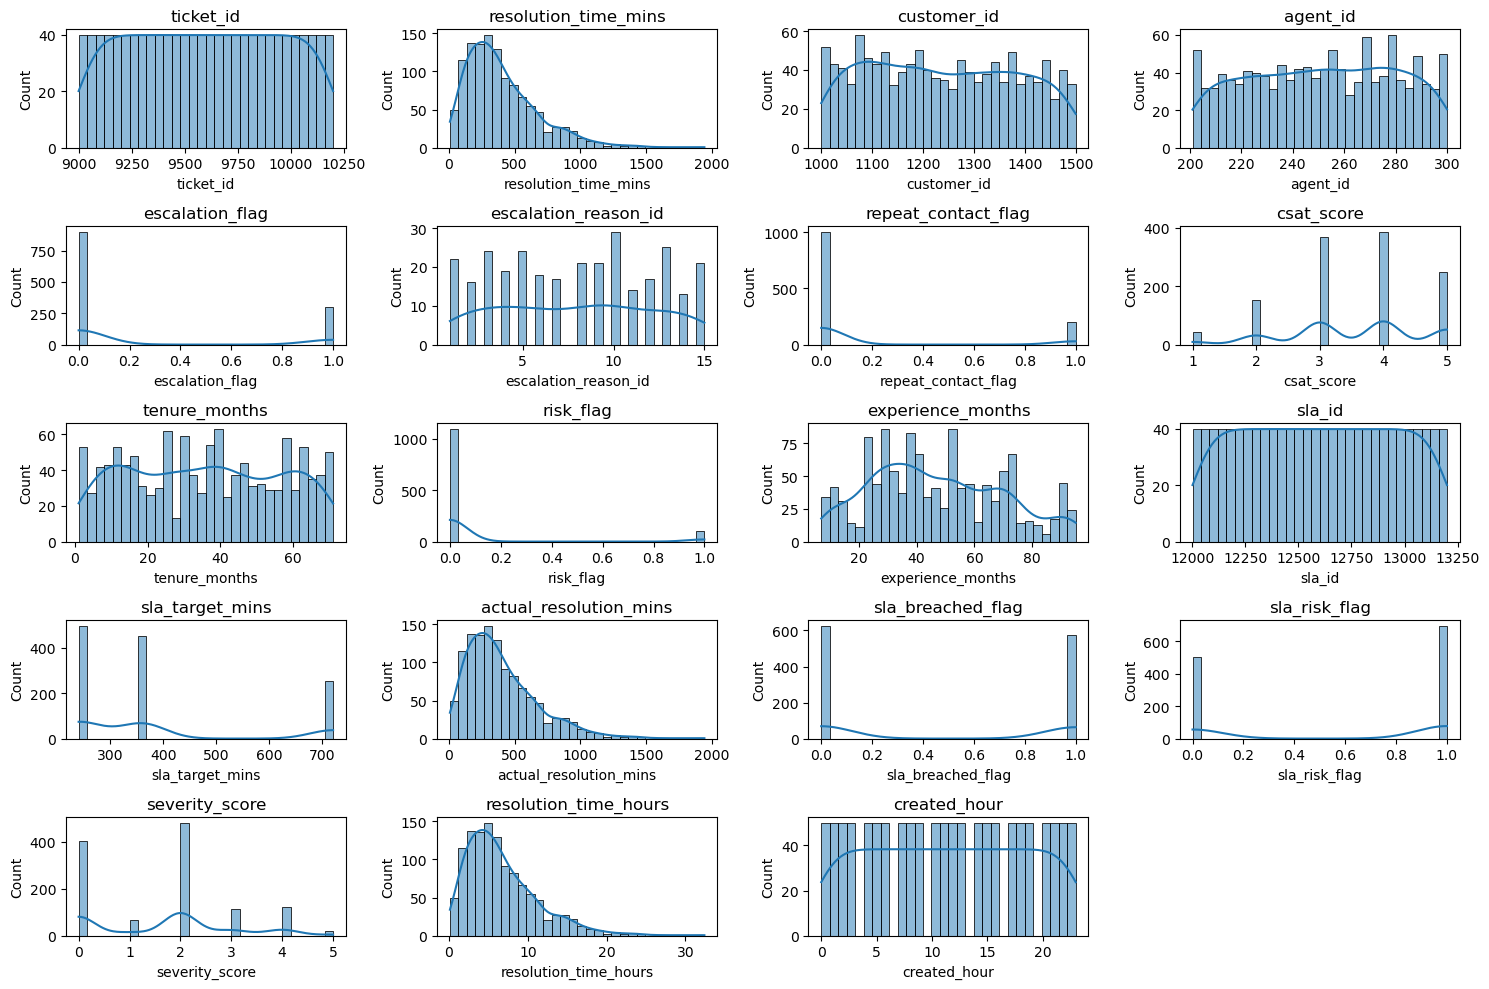

In [9]:
# Distribution plots for numerical cols
numerical_cols = df.select_dtypes(include= np.number).columns        # selecting numerical columns

plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(5,4, i+1)                                            # Adjust grid layout as needed
    sns.histplot(df[col], kde=True, bins= 30)
    plt.title(col)

plt.tight_layout()
plt.show()

#### **Conclusion:**

> **Escalations**
- escalation_flag → Highly skewed toward 0 and escalation_reason_id → Spread across multiple categories, repeat_contact_flag → Mostly 0 and risk_flag → Very rare 1s, that means, repeat contacts are rare but likely correlated with escalations. This suggests,
  
    `Hypothesis - Escalations are low in volume but concentrated among repeat-contact tickets and higher severity cases.`
  
- escalations are not dominated by one reason, which enables:
    - Root cause analysis
    - Pareto analysis (top 20% reasons causing 80% escalations)

> **SLA Performance (controlled targets, variable execution)**
- sla_target_mins → Discrete bands (300, 360, 420, 720, etc.), actual_resolution_mins → Right-skewed, long tail, sla_breached_flag → Mostly 0, some 1s, sla_risk_flag → Very small high-risk population.
- This suggests, SLA targets are policy-driven (fixed thresholds).
- Actual resolution time reflects operational reality:
    - Most tickets resolved fast
    - A minority take very long → SLA breaches
- Risk flag is doing its job: early warning, not over-triggering.

  `SLA breaches are driven by a small subset of long-running tickets rather than systemic SLA target issues.`

> **CSAT (believable, nuanced distribution)**
- csat_score → Discrete 1–5, peaks around 3–4, no artificial clustering at only 4–5 and long tail toward low scores.
- This tells, CSAT scores are authentic and not inflated. Neutral scores (3) are common and there is a room for improvement analysis considering low CSAT scores.
- Low CSAT likely correlates with:
    - Repeat contact
    - Escalation
    - SLA breach

> **Resolution time: operational bottleneck signal**
- resolution_time_mins & resolution_time_hours are strongly skewed in the right, so there are few extreme cases.
- Hence, this dataset has **operational bottlenecks**, not only averages.
- Long tail cases are likely:
    - escalated
    - SLA-breached
    - low CSAT
    
    `A small proportion of tickets disproportionately impacts SLA compliance and customer satisfaction`

> **Agent & Customer Dimensions**
- Agent experience & tenures are Widely spreaded, Customer IDs & segments are distributed in balanced way, created_hour shows even coverage across day.
- This enables:
    - Agent performance vs experience analysis
    - Shift-based SLA/CSAT analysis
    - Customer segment risk profiling (Standard vs Ultra, etc.)

#### Data Overview 

- Escalations represent less than X% of total tickets but account for a disproportionate share of SLA breaches and low CSAT.
- Resolution time exhibits a heavy right-tail, indicating operational bottlenecks rather than widespread inefficiency.
- SLA breaches are concentrated among repeat-contact and escalated tickets.
- CSAT declines sharply when SLA is breached, validating SLA as a leading indicator of customer dissatisfaction.

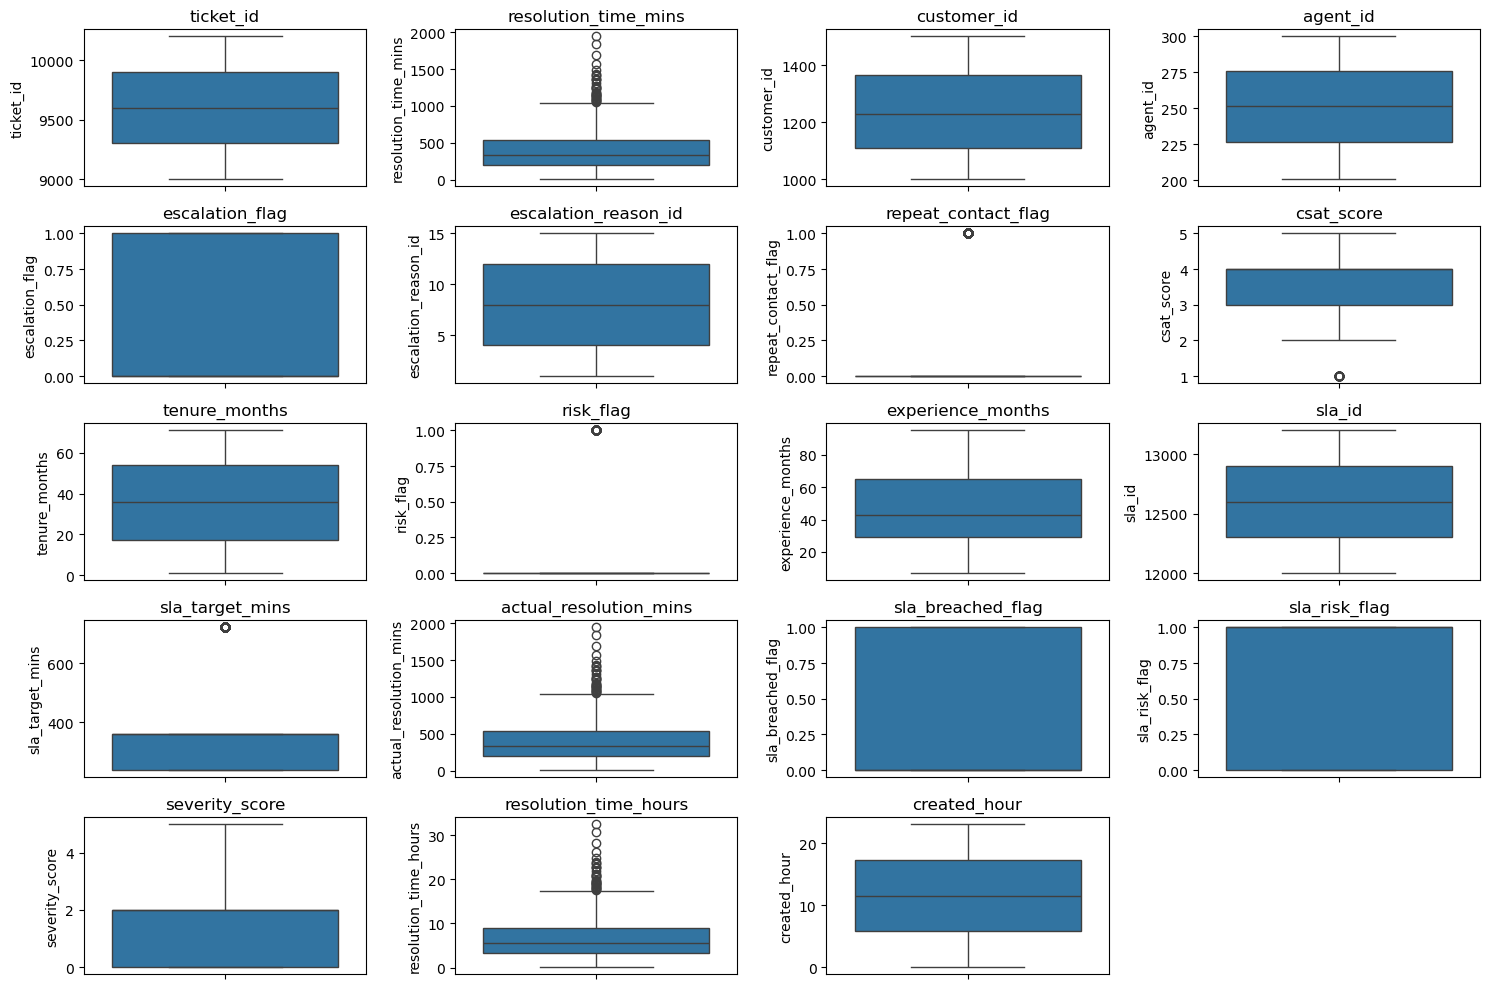

In [12]:
# Outlier Detection with boxplots

plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(5,4, i+1)                                            # Adjust grid layout as needed
    sns.boxplot(y = df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

#### Insights:

- `Resolution times` show high dispersion and pronounced right skew, with many observations exceeding the upper quartile. This indicates process variability and the presence of long-running cases that materially impact SLA compliance and customer experience.
- SLA targets are tier-based or severity-based. Higher targets likely apply to:
  - Complex issues
  - Lower-priority queues
- `csat_score` has median around 3–4 and occasional low scores. This says, low CSAT outliers correlate with escalations and SLA breaches.

> Outliers in resolution time and CSAT represent genuine operational bottlenecks and customer dissatisfaction events, not data errors. Binary flag outliers reflect low-frequency but high-impact events and were retained. No outliers were removed during EDA to preserve business signal.”

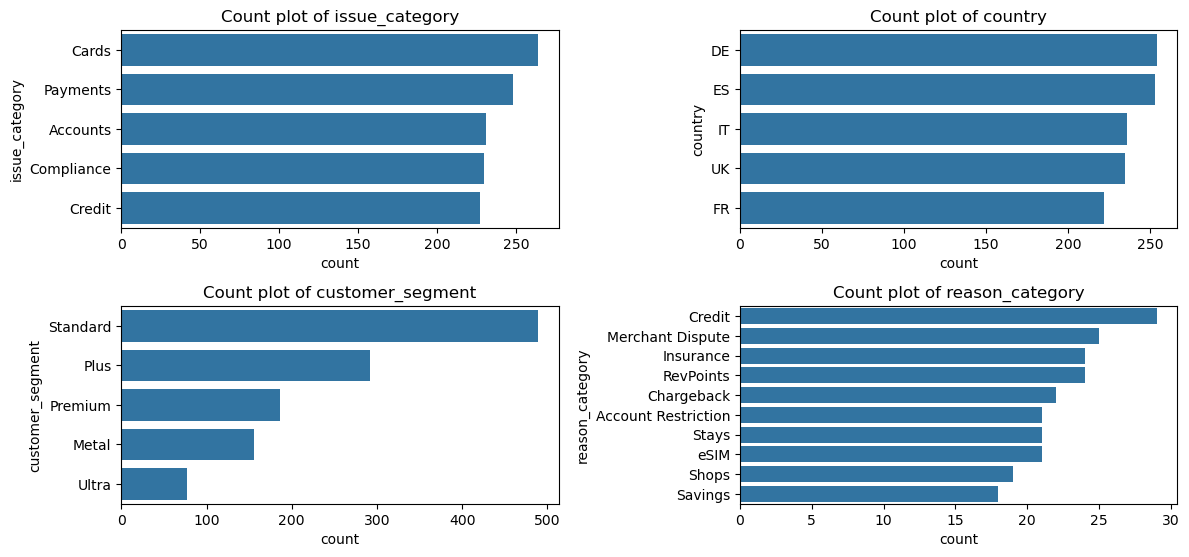

In [14]:
# Count Plots for Categoriacl cols
categorical_cols = ['issue_category', 'country', 'customer_segment', 'reason_category']        # selecting numerical columns

plt.figure(figsize=(12,8))
for i, col in enumerate(categorical_cols):
    plt.subplot(3,2, i+1)                                            # Adjust grid layout as needed
    sns.countplot(df[col], order= df[col].value_counts().index[:10])    # Top 10 categories
    plt.title(f"Count plot of {col}")

plt.tight_layout()
plt.show()

#### Insights: 
> Ticket volume is distributed across multiple issue categories and countries, with Standard customers contributing the majority of demand. Credit and dispute-related reasons are the most frequent and likely drivers of operational complexity.
> 
> These distributions guide targeted correlation analysis across escalation rates, SLA breaches, and CSAT outcomes.”

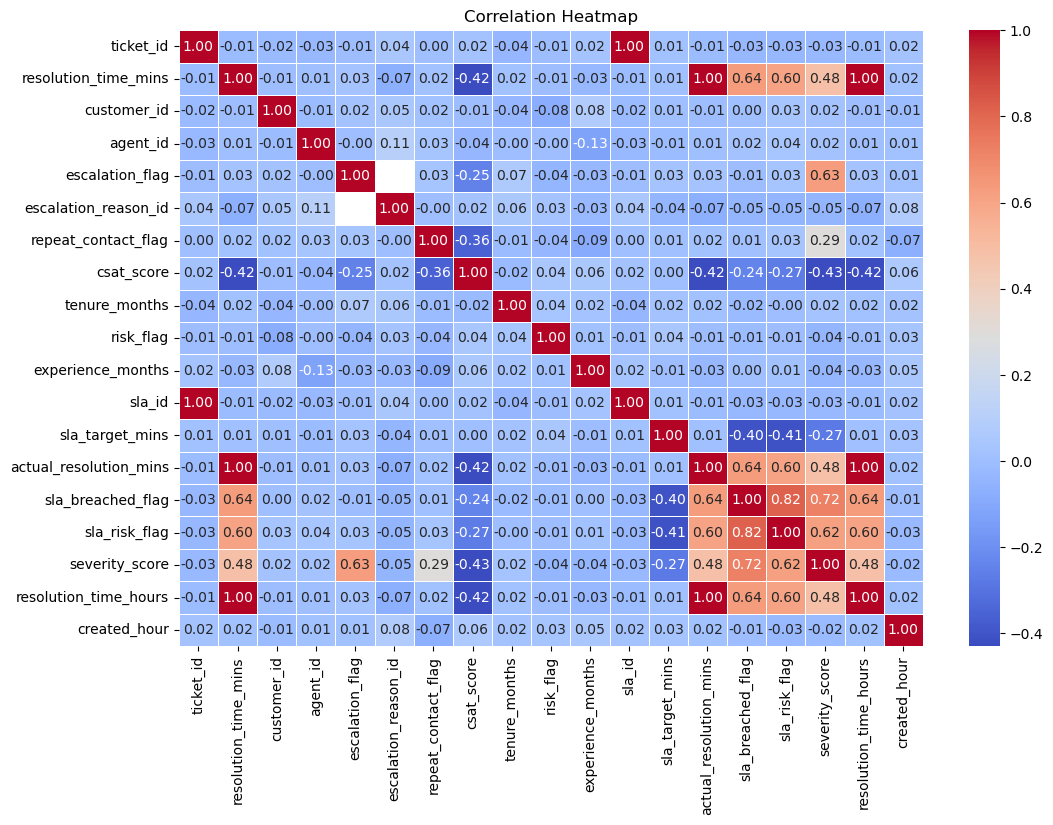

In [16]:
# Correlation heatmap

plt.figure(figsize= (12,8))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot= True, fmt= '.2f', cmap= 'coolwarm', linewidths= 0.5)

plt.title("Correlation Heatmap")
plt.show()

#### Insights:
> Correlation analysis indicates that severity and resolution time are the strongest drivers of SLA breaches, escalations, and reduced customer satisfaction, while agent experience and temporal factors exhibit minimal linear impact. These findings support a process-centric view of performance rather than an individual-centric one.

### Research Questions

#### **1. Which issue categories disproportionately drive escalations?**

**`Bar chart (Escalation Rate by Issue Category)`**
→ Categories are discrete; rates are comparative.

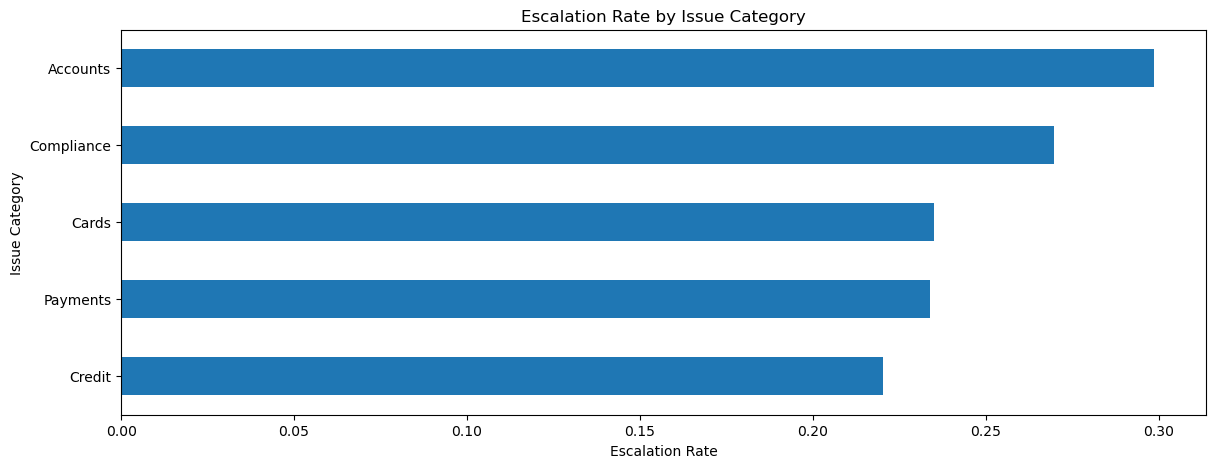

In [21]:
# (Escalated tickets / total tickets per category)

esc_issue = (
    df.groupby('issue_category')
    .agg(
        total=('ticket_id', 'count'),
        escalations=('escalation_flag', 'sum')
    )
)
esc_issue['escalation_rate'] = esc_issue['escalations'] / esc_issue['total']

esc_issue.sort_values('escalation_rate').plot(
    kind='barh',
    y='escalation_rate',
    legend=False,
    figsize=(14,5)
)

plt.title('Escalation Rate by Issue Category')
plt.xlabel('Escalation Rate')
plt.ylabel('Issue Category')
plt.show()

> **Conclusion:**
>   
> Although Cards and Payments generate high ticket volumes, escalation risk is highest for Accounts and Compliance-related issues. Credit and Payments show the lowest escalation rates, indicating that escalation is driven by issue complexity rather than ticket frequency.

#### Statistical Validation: Chi-Square Test

In [24]:
# Purpose: Test whether escalation likelihood differs by issue category. Chi-square confirms whether differences are statistically significant

from scipy.stats import chi2_contingency

contingency = pd.crosstab(df['issue_category'], df['escalation_flag'])
chi2, p, dof, exp = chi2_contingency(contingency)

print(f"Chi-square: {chi2:.2f}, p-value: {p:.4f}")

Chi-square: 5.11, p-value: 0.2758


> **Conclusion:**
>
> With p-value > 0.05, we fail to reject the null hypothesis - Escalation likelihood is independent of issue category. There is no statistically significant evidence that escalation rates differ by issue category.


**While escalation rates vary visually across issue categories, statistical testing does not support a significant association. This suggests that escalations are likely driven by underlying factors such as severity, resolution time, or SLA risk rather than issue category in isolation.**

**2. How does resolution time impact CSAT?**

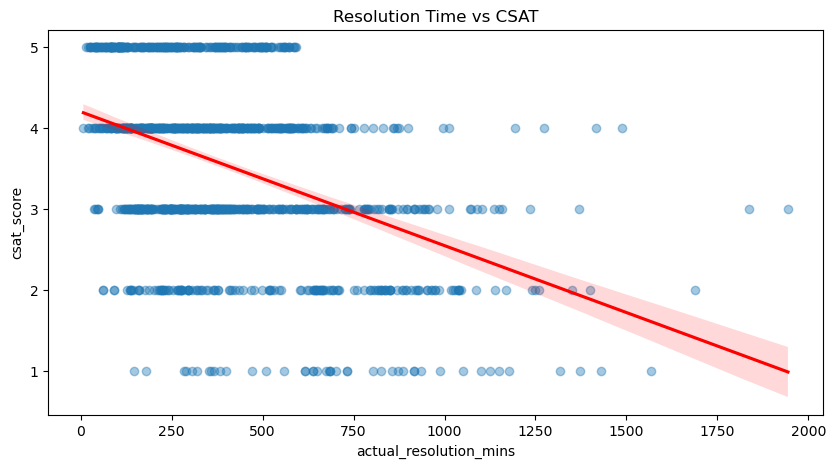

In [27]:
# scatter and trend

plt.figure(figsize=(10,5))
sns.regplot(
    data=df,
    x='actual_resolution_mins',
    y='csat_score',
    scatter_kws={'alpha':0.4},
    line_kws={'color':'red'}
)
plt.title("Resolution Time vs CSAT")
plt.show()

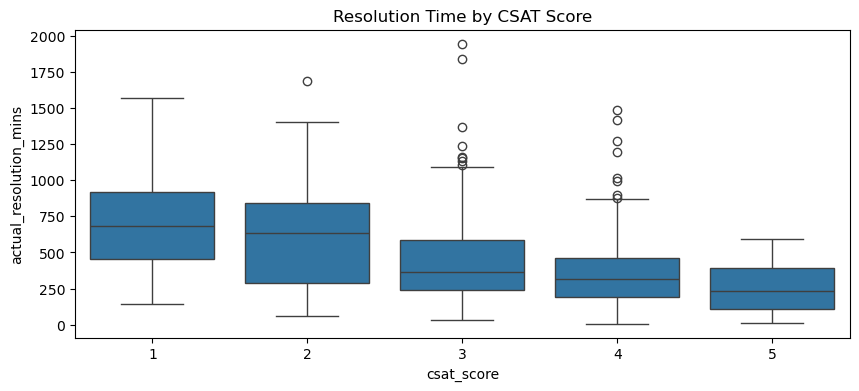

In [28]:
# boxplot - csat groups

plt.figure(figsize=(10,4))
sns.boxplot(
    data=df,
    x='csat_score',
    y='actual_resolution_mins'
)
plt.title("Resolution Time by CSAT Score")
plt.show()

> **Conclusion:**
> 
> With lower CSAT groups (1–2) having higher medians and wider IQRs, it's inferred that Resolution time has a statistically significant negative impact on CSAT.
> Tickets resolved more slowly consistently receive lower satisfaction scores, confirming timeliness as a primary driver of customer experience.

**3. Are SLA breaches concentrated in specific issue categories?**

This ties process failures to business areas.

**Visuals Used**
- Bar chart: SLA breach rate (%) by issue category
- Heatmap: Issue category × SLA breach rate (normalized)

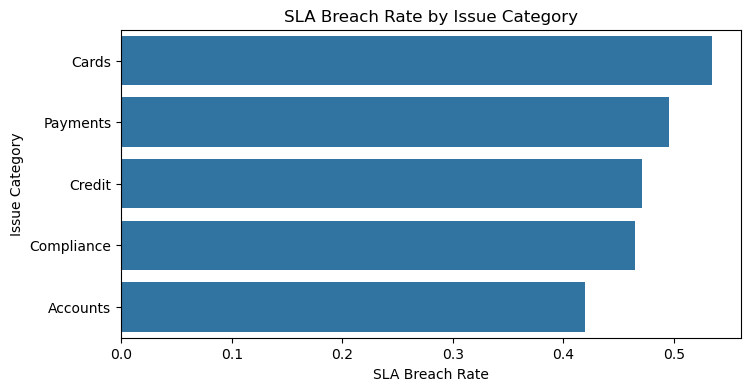

In [31]:
# sla_breach_rate by issue_category

sla_rate = (
    df.groupby('issue_category')['sla_breached_flag']
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,4))
sns.barplot(x=sla_rate.values, y=sla_rate.index)
plt.xlabel("SLA Breach Rate")
plt.ylabel("Issue Category")
plt.title("SLA Breach Rate by Issue Category")
plt.show()

##### The bar chart shows variation in SLA breach rates across issue categories, with Cards and Payments appearing higher than Accounts.

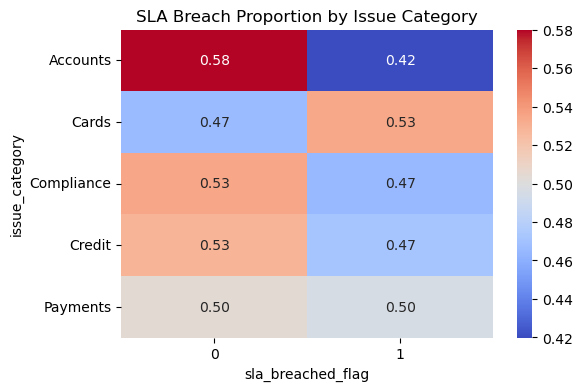

In [32]:
sla_heat = pd.crosstab(
    df['issue_category'],
    df['sla_breached_flag'],
    normalize='index'
)

plt.figure(figsize=(6,4))
sns.heatmap(sla_heat, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("SLA Breach Proportion by Issue Category")
plt.show()

In [44]:
# statistical test | Variables: issue_category × sla_breached_flag

contingency = pd.crosstab(df['issue_category'], df['sla_breached_flag'])
chi2, p, _, _ = chi2_contingency(contingency)

print(f"Chi-square: {chi2:.2f}, p-value: {p:.4f}")

Chi-square: 6.96, p-value: 0.1382


##### Chi-square test of independence (χ² = 6.96, p = 0.138) indicates that these differences are not statistically significant.

**Conclusion:**

> This suggests that the observed variation may be due to random sampling variation rather than a true underlying relationship.Therefore, issue category alone is not a strong predictor of SLA breach, and other factors such as resolution time and severity are likely more influential.

**4. Does agent tier influence escalation & resolution outcomes?**

In [35]:
# create agent-tier

df['agent_tier'] = pd.cut(
    df['experience_months'],
    bins=[0, 24, 60, np.inf],
    labels=['Junior', 'Mid', 'Senior']
)


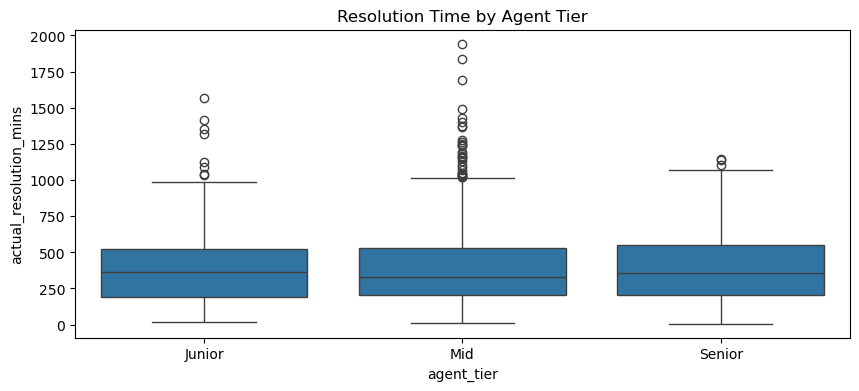

In [56]:
# Box Plot - resolution time by agent tier

plt.figure(figsize=(10,4))
sns.boxplot(
    data=df,
    x='agent_tier',
    y='actual_resolution_mins'
)
plt.title("Resolution Time by Agent Tier")
plt.show()

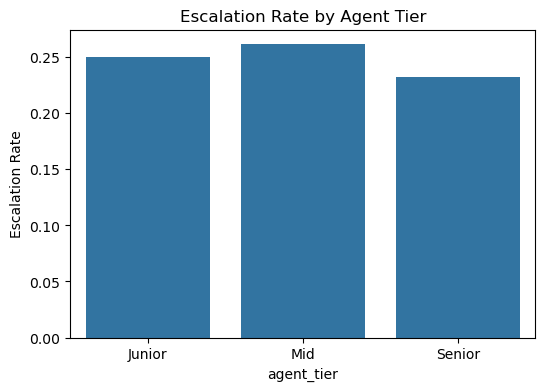

In [58]:
# Bar chart: Escalation rate (%) by agent tier

tier_esc = df.groupby('agent_tier')['escalation_flag'].mean()

plt.figure(figsize=(6,4))
sns.barplot(x=tier_esc.index, y=tier_esc.values)
plt.ylabel("Escalation Rate")
plt.title("Escalation Rate by Agent Tier")
plt.show()

**Statistical Tests**

In [61]:
# Resolution time across agent tiers
from scipy import stats

groups = [
    df[df['agent_tier'] == t]['actual_resolution_mins']
    for t in df['agent_tier'].dropna().unique()
]

stat, p = kruskal(*groups)
print(f"Kruskal-Wallis stat: {stat:.2f}, p-value: {p:.4f}")

NameError: name 'kruskal' is not defined

In [63]:
# Agent tier vs Escalation_flag 
contingency = pd.crosstab(df['agent_tier'], df['escalation_flag'])
chi2, p, _, _ = chi2_contingency(contingency)

print(f"Chi-square: {chi2:.2f}, p-value: {p:.4f}")

Chi-square: 1.03, p-value: 0.5966


**Conclusion:**

> “Chi-square testing (χ² = 1.03, p = 0.5966) shows no statistically significant association between agent tier and escalation likelihood. This suggests that escalation outcomes are not strongly dependent on agent experience level and are more likely influenced by underlying factors such as ticket complexity and resolution requirements.”

**5. What factors most strongly correlate with repeat contacts?**

**Visuals Used:**
- Correlation heatmap (focused subset only)
   - Repeat contact, Resolution time, SLA breach, escalation, severity, CSAT
- Boxplots: Resolution time by repeat contact flag
- Bar chart: Repeat contact rate by issue category

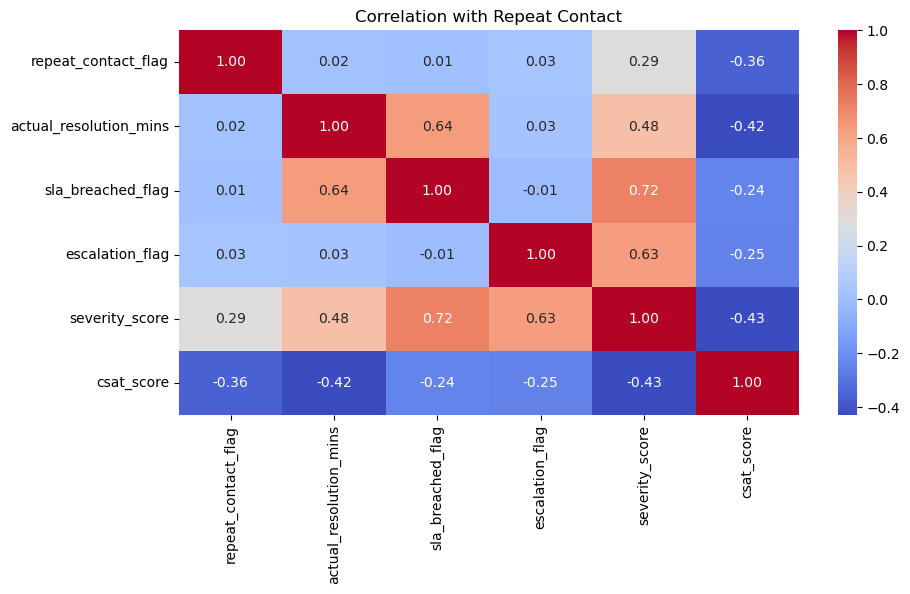

In [73]:
# Correlation heatmap 

cols = [
    'repeat_contact_flag',
    'actual_resolution_mins',
    'sla_breached_flag',
    'escalation_flag',
    'severity_score',
    'csat_score'
]

plt.figure(figsize=(10,5))
sns.heatmap(
    df[cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)
plt.title("Correlation with Repeat Contact")
plt.show()

##### Heatmap identifies strongest linear associations.

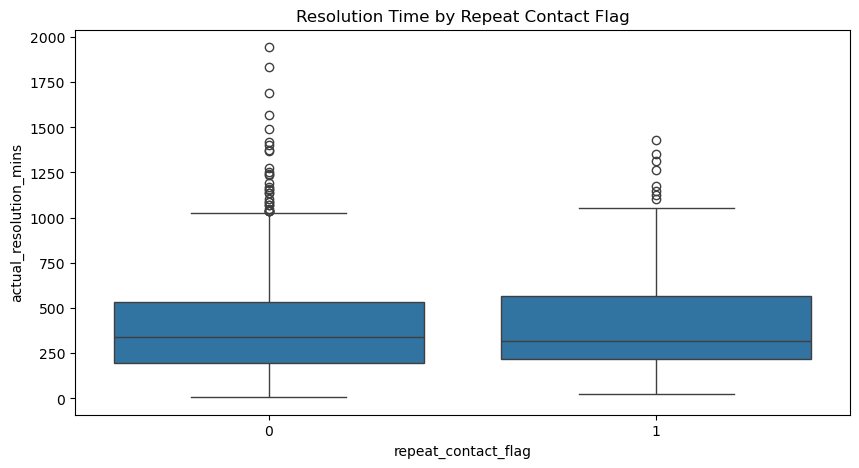

In [76]:
# resolution time vs repeat contact

plt.figure(figsize=(10,5))
sns.boxplot(
    data=df,
    x='repeat_contact_flag',
    y='actual_resolution_mins'
)
plt.title("Resolution Time by Repeat Contact Flag")
plt.show()

##### Boxplots confirm distributional differences.

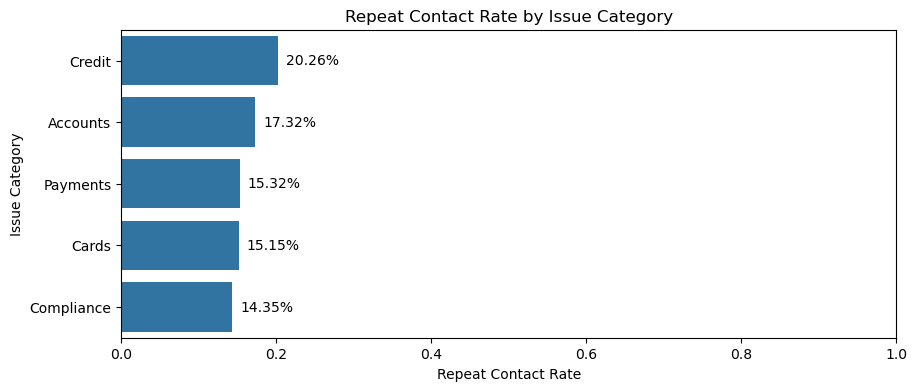

In [109]:
# bar chart - Repeat contact rate vs issue category

repeat_rate = (
    df.groupby('issue_category')['repeat_contact_flag']
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10, 4))

ax = sns.barplot(
    x=repeat_rate.values,
    y=repeat_rate.index
)

# Add labels
for i, v in enumerate(repeat_rate.values):
    ax.text(v + 0.01, i, f"{v:.2%}", va='center')

plt.xlabel("Repeat Contact Rate")
plt.ylabel("Issue Category")
plt.title("Repeat Contact Rate by Issue Category")

plt.xlim(0, 1)  # since it's a rate (0–1)

plt.show()

#### Statistical Test: Point-biserial (via Spearman)

##### Why used Spearman instead?
- Data is not normally distributed
- Relationships may not be strictly linear
- CSAT is ordinal (1–5)
  
So Spearman is more robust.

In [93]:
# Repeat contact (binary) vs continuous variables('actual_resolution_mins', 'severity_score', 'csat_score')
# Point-biserial correlation measures the relationship between a binary variable and a continuous variable.

# “Do tickets with repeat contact behave differently (in terms of resolution time, severity, CSAT) compared to those without repeat contact?”

from scipy.stats import spearmanr

for col in ['actual_resolution_mins', 'severity_score', 'csat_score']:
    rho, p = spearmanr(df['repeat_contact_flag'], df[col])
    print(f"{col}: rho={rho:.3f}, p={p:.4f}")

actual_resolution_mins: rho=0.004, p=0.8958
severity_score: rho=0.314, p=0.0000
csat_score: rho=-0.335, p=0.0000


**Resolution Time vs Repeat Contact**

With ρ = 0.004 (≈ 0) and p = 0.8958 (not significant), we can interpret, there is virtually NO relationship
Statistically insignificant → could be random.
> That means, **resolution time does not influence whether customers contact again. This contradicts earlier hypothesis (“Longer resolution time → more repeat contact”)**

**Severity Score vs Repeat Contact**

With ρ = 0.314 (moderate positive) and p < 0.001 (highly significant), we can interpret that as severity increases → repeat contact increases. Thatmeans, more complex / critical issues are more likely to require multiple interactions)
Relationship is statistically strong and reliable
> “Severity is a significant driver of repeat contacts, indicating that more complex issues often require multiple touchpoints for resolution.”

**CSAT vs Repeat Contact**

With ρ = -0.335 (moderate negative) and p < 0.001 (highly significant), we can interpret that as CSAT decreases → repeat contact increases, Strong inverse relationship. That means, customers who are dissatisfied are more likely to reach out again.
> “Repeat contacts are strongly associated with lower customer satisfaction, suggesting unresolved or poorly handled issues drive re-engagement.”

**Final Conclusion:**
> “Repeat contacts are not driven by resolution time, but are significantly associated with higher severity and lower CSAT. This indicates that repeat interactions are primarily caused by issue complexity and unresolved customer dissatisfaction rather than delays in resolution.”

### Final EDA Synthesis

>“EDA reveals that escalation and SLA performance are driven primarily by issue complexity and resolution time rather than agent or temporal factors. Customer satisfaction declines significantly as resolution time increases and repeat contacts occur. Visual and statistical alignment across multiple methods confirms that operational outcomes are process-driven, with specific issue categories acting as consistent risk multipliers.”